# CE639: AI for Civil Engineering
## Lecture 06: Regression Models
### Scientific Computing Fundamentals

**Instructors:** Dr. Udit Bhatia & Dr. Sushobhan Sen  
**Tutor:** Sarth Dubey  
**Institution:** IIT Gandhinagar

---

### Learning Objectives

By the end of this notebook, you will be able to:
- Develop linear, polynomial, and kernel regression models
- Define various error metrics (RMSE, MAE, NSE)
- Apply regression to Civil Engineering problems

## 🔧 Setup and Installation

In [ ]:
# Install dependencies (for Google Colab)
import sys
import os
import subprocess

def install_package(package):
    """Install a package using pip."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab ✓")
except:
    IN_COLAB = False
    print("Running locally ✓")

# # Install required packages
# required_packages = ['numpy', 'matplotlib', 'scipy', 'ipywidgets']
# for package in required_packages:
#     try:
#         __import__(package)
#     except ImportError:
#         print(f"Installing {package}...")
#         install_package(package)

# print("\n✓ All packages installed successfully!")

Running locally ✓


In [2]:
if IN_COLAB:
    # !git clone https://github.com/dubeysarth/2026_IITGN_CE639
    # %cd 2026_IITGN_CE639
    subprocess.run(['git', 'clone', 'https://github.com/dubeysarth/2026_IITGN_CE639'])
    os.chdir('2026_IITGN_CE639')

In [3]:
# Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
%matplotlib inline

# Import our custom helper utilities
import sys
sys.path.append('/content')  # For Colab
sys.path.append('..')  # For local

from utils.Lecture_06 import (
    # Linear Regression
    ols_fit, ridge_fit, lasso_fit, linear_predict, linear_regression_gd,
    standardize_features, normalize_features,
    # Polynomial Regression
    polynomial_features, polynomial_fit, polynomial_predict,
    # Kernel Regression
    linear_kernel, polynomial_kernel, rbf_kernel, kernel_matrix,
    kernel_regression_fit, kernel_regression_predict,
    # Error Metrics
    mae, mape, mse, rmse, nse, r_squared, compute_all_metrics,
    # Visualizations
    plot_regression_fit, plot_residuals, plot_kernel_comparison,
    plot_polynomial_degrees, plot_regularization_path, plot_error_metrics,
    # Widgets
    linear_regression_widget, polynomial_degree_widget, kernel_explorer_widget,
    regularization_widget, error_metric_widget,
    # CE Examples
    concrete_strength_data, traffic_flow_data, pavement_deflection_data
)

print("✓ All imports successful!")
print("=" * 70)
print("Ready to explore Regression Models!")
print("=" * 70)

✓ All imports successful!
Ready to explore Regression Models!


---
# 📚 Section 1: Learning Types

## Supervised vs Unsupervised Learning

In AI/ML, we are generally interested in two main types of problems:

### **Supervised Learning**
- Train a model to predict from a **labeled** dataset
- We have input-output pairs: $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$
- Two subtypes:
  - **Classification**: Label is categorical (e.g., crack/no crack)
  - **Regression**: Label is continuous (e.g., strength, deflection)

### **Unsupervised Learning**
- Find patterns in **unlabeled** data
- No target outputs provided
- Examples: clustering, dimensionality reduction

### **Other Types** (not covered today)
- **Reinforcement Learning**: Agent learns through rewards
- **Self-Supervised Learning**: Create labels from data itself

**Today's Focus:** Regression (supervised learning with continuous outputs)

## CE Examples of Regression

| Problem | Inputs | Output |
|---------|--------|--------|
| Concrete Strength | Cement, water, age | Compressive strength (MPa) |
| Traffic Flow | Time, weather, location | Vehicles per hour |
| Pavement Deflection | Load, thickness, temperature | Surface deflection (mm) |
| Beam Deflection | Span, load, moment of inertia | Maximum deflection (mm) |
| Soil Settlement | Pressure, thickness, void ratio | Settlement (mm) |

---
# 📐 Section 2: Linear Regression

## The Linear Model

Linear regression aims to find a model of the form:

$$f(\mathbf{x}) = \mathbf{w}^T \mathbf{x} + b$$

where:
- $\mathbf{w}$ is the **weight vector** (coefficients)
- $b$ is the **bias** (intercept)

In matrix form for a dataset:

$$\mathbf{y} = \mathbf{X} \mathbf{w} + \boldsymbol{\varepsilon}$$

where $\boldsymbol{\varepsilon} \sim N(0, \sigma^2)$ is noise.

## Ordinary Least Squares (OLS)

**Objective:** Minimize the Mean Squared Error (MSE)

$$L(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2$$

**Closed-form solution:**

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

This is the **pseudoinverse** solution!

**Properties:**
- Convex optimization → unique global minimum
- Fast and interpretable
- Limited expressiveness (cannot model nonlinear patterns)

Linear Regression Example
True model: y = 2x + 1
Fitted model: y = 1.981x + 0.992

Metrics:
  RMSE: 0.4536
  R²:   0.9825


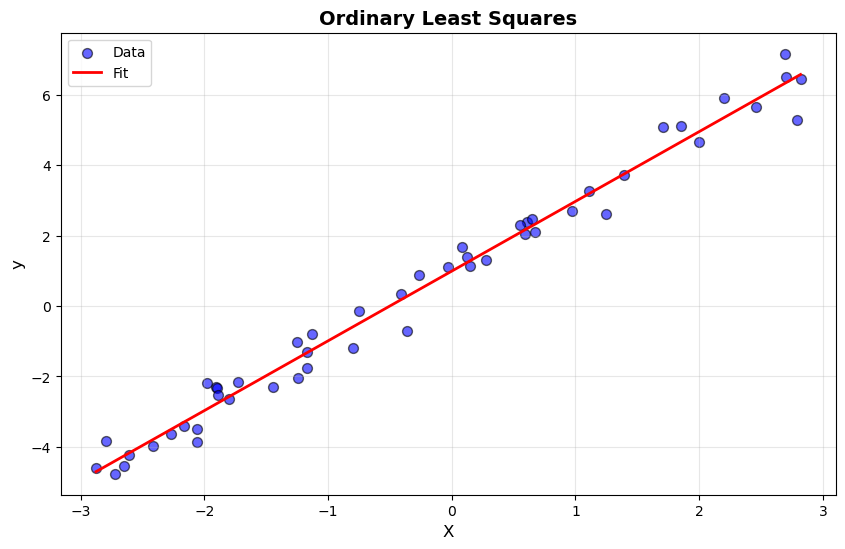

In [4]:
# Demonstrate OLS
print("Linear Regression Example")
print("=" * 60)

# Generate synthetic data
np.random.seed(42)
n_samples = 50
X = np.random.uniform(-3, 3, n_samples)
y_true = 2 * X + 1
y = y_true + np.random.normal(0, 0.5, n_samples)

# Fit OLS
X_2d = X.reshape(-1, 1)
w = ols_fit(X_2d, y)

print(f"True model: y = 2x + 1")
print(f"Fitted model: y = {w[1]:.3f}x + {w[0]:.3f}")

# Predict
y_pred = linear_predict(X_2d, w)

# Compute metrics
metrics = compute_all_metrics(y, y_pred)
print(f"\nMetrics:")
print(f"  RMSE: {metrics['RMSE']:.4f}")
print(f"  R²:   {metrics['R²']:.4f}")

# Plot
fig, ax = plot_regression_fit(X, y, y_pred, title="Ordinary Least Squares")
plt.show()

## Gradient Descent Alternative

For large datasets, computing $(\mathbf{X}^T \mathbf{X})^{-1}$ can be expensive.

**Alternative:** Use gradient descent with backpropagation

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \alpha \nabla L(\mathbf{w}_t)$$

where $\nabla L = \frac{2}{n} \mathbf{X}^T (\mathbf{X}\mathbf{w} - \mathbf{y})$

OLS vs Gradient Descent Comparison
OLS weights:     [0.9925, 1.9814]
GD weights:      [0.9925, 1.9814]
Final GD loss:   0.205768


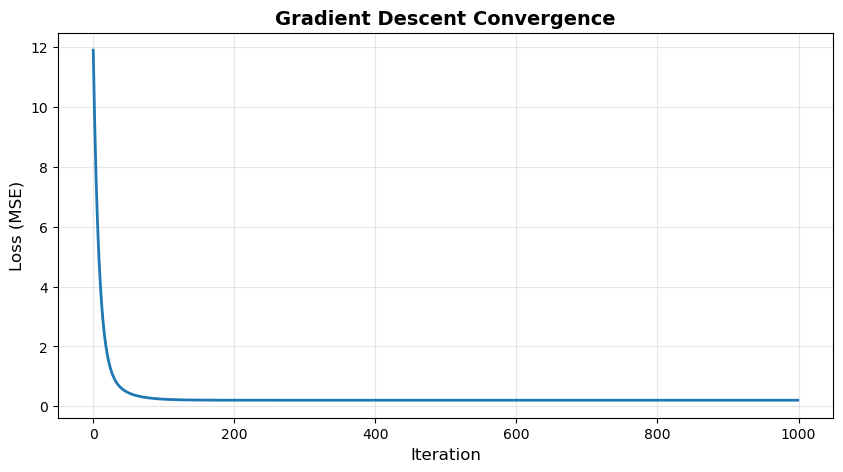

In [5]:
# Compare OLS vs Gradient Descent
result_gd = linear_regression_gd(X_2d, y, learning_rate=0.01, n_iterations=1000)

print("OLS vs Gradient Descent Comparison")
print("=" * 60)
print(f"OLS weights:     [{w[0]:.4f}, {w[1]:.4f}]")
print(f"GD weights:      [{result_gd['weights'][0]:.4f}, {result_gd['weights'][1]:.4f}]")
print(f"Final GD loss:   {result_gd['loss_history'][-1]:.6f}")

# Plot loss history
plt.figure(figsize=(10, 5))
plt.plot(result_gd['loss_history'], linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Loss (MSE)', fontsize=12)
plt.title('Gradient Descent Convergence', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

---
# ⚖️ Section 3: Feature Scaling

## Why Scale Features?

**Problem:** Features with different scales can cause issues:
- Gradient descent converges slowly
- Some features dominate others
- Regularization affects features unequally

**Solution:** Standardize or normalize features

### Standardization (Z-score)
$$x' = \frac{x - \mu}{\sigma}$$

### Normalization (Min-Max)
$$x' = \frac{x - x_{min}}{x_{max} - x_{min}}$$

In [6]:
# Demonstrate feature scaling
print("Feature Scaling Example")
print("=" * 60)

# Generate data with different scales
X_multi = np.column_stack([
    np.random.uniform(0, 1, 50),      # Feature 1: [0, 1]
    np.random.uniform(0, 1000, 50)    # Feature 2: [0, 1000]
])
y_multi = 2 * X_multi[:, 0] + 0.5 * X_multi[:, 1] + np.random.normal(0, 10, 50)

# Fit without scaling
w_unscaled = ols_fit(X_multi, y_multi)

# Fit with scaling
X_scaled, mean, std = standardize_features(X_multi)
w_scaled = ols_fit(X_scaled, y_multi)

print("Without scaling:")
print(f"  Weights: {w_unscaled[1:]}")
print(f"\nWith standardization:")
print(f"  Weights: {w_scaled[1:]}")
print(f"\nNotice: Scaled weights are more balanced!")

Feature Scaling Example
Without scaling:
  Weights: [6.87946655 0.49271345]

With standardization:
  Weights: [  1.96534285 146.10281987]

Notice: Scaled weights are more balanced!


---
# 🎯 Section 4: Regularization

## Ridge Regression (L2)

Add penalty on weight magnitude:

$$L(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda ||\mathbf{w}||_2^2$$

**Closed-form solution:**

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

**Effect:** Shrinks weights toward zero, prevents overfitting

## LASSO Regression (L1)

Use L1 penalty instead:

$$L(\mathbf{w}) = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2 + \lambda ||\mathbf{w}||_1$$

**Effect:** 
- Promotes **sparsity** (some weights become exactly zero)
- Performs feature selection
- No closed-form solution (use optimization)

In [7]:
# Compare Ridge vs LASSO
print("Ridge vs LASSO Comparison")
print("=" * 60)

# Generate data with many features (some irrelevant)
np.random.seed(42)
n_samples = 100
n_features = 10
X_many = np.random.randn(n_samples, n_features)

# Only first 3 features are relevant
true_weights = np.array([2, -1, 0.5] + [0] * 7)
y_many = X_many @ true_weights + 0.5 * np.random.randn(n_samples)

# Fit models
lambda_reg = 1.0
w_ridge = ridge_fit(X_many, y_many, lambda_reg=lambda_reg)
w_lasso = lasso_fit(X_many, y_many, lambda_reg=lambda_reg)

print(f"True weights (non-zero): [2, -1, 0.5, 0, 0, ...]")
print(f"\nRidge weights: {w_ridge[1:]}")
print(f"LASSO weights: {w_lasso[1:]}")

# Count non-zero weights
threshold = 0.01
n_nonzero_ridge = np.sum(np.abs(w_ridge[1:]) > threshold)
n_nonzero_lasso = np.sum(np.abs(w_lasso[1:]) > threshold)

print(f"\nNon-zero weights (|w| > {threshold}):")
print(f"  Ridge: {n_nonzero_ridge}/{n_features}")
print(f"  LASSO: {n_nonzero_lasso}/{n_features}")
print(f"\nLASSO achieves sparsity!")

Ridge vs LASSO Comparison
True weights (non-zero): [2, -1, 0.5, 0, 0, ...]

Ridge weights: [ 1.93013505e+00 -1.01597492e+00  4.85538616e-01  1.10241215e-02
 -6.65981468e-02  3.95070378e-02 -9.24528916e-02 -1.68877441e-03
  2.84488833e-02 -2.84591813e-02]
LASSO weights: [ 1.42200584e+00 -5.51441641e-01  2.51307729e-02 -4.63433650e-09
 -9.10884691e-09 -5.53675150e-09 -2.35450293e-09 -6.26004890e-09
  1.13558690e-09 -5.47810827e-09]

Non-zero weights (|w| > 0.01):
  Ridge: 9/10
  LASSO: 3/10

LASSO achieves sparsity!


### 🎮 Interactive Widget: Regularization Explorer

In [8]:
regularization_widget()

interactive(children=(FloatSlider(value=1.0, description='λ:', max=10.0, step=0.5), Output()), _dom_classes=('…

---
# �� Section 5: Polynomial Regression

## Feature Transformation

Linear regression is **linear in parameters**, not necessarily in inputs!

**Polynomial regression** uses nonlinear feature transformations:

$$\phi(\mathbf{x}) = [1, x, x^2, x^3, \ldots, x^p]$$

Then fit:

$$f(\mathbf{x}) = \mathbf{w}^T \phi(\mathbf{x})$$

**Example:** For $x = 2$ and degree 3:
$$\phi(2) = [1, 2, 4, 8]$$

In [9]:
# Demonstrate polynomial features
x_example = np.array([2.0])
for degree in [1, 2, 3]:
    phi = polynomial_features(x_example.reshape(-1, 1), degree=degree)
    print(f"Degree {degree}: φ(2) = {phi[0]}")

Degree 1: φ(2) = [1. 2.]
Degree 2: φ(2) = [1. 2. 4.]
Degree 3: φ(2) = [1. 2. 4. 8.]


## Choosing Polynomial Degree

**Tradeoff:**
- **Low degree:** High bias → underfitting
- **High degree:** High variance → overfitting

**Solution:** Use regularization or cross-validation

Polynomial Degree Comparison


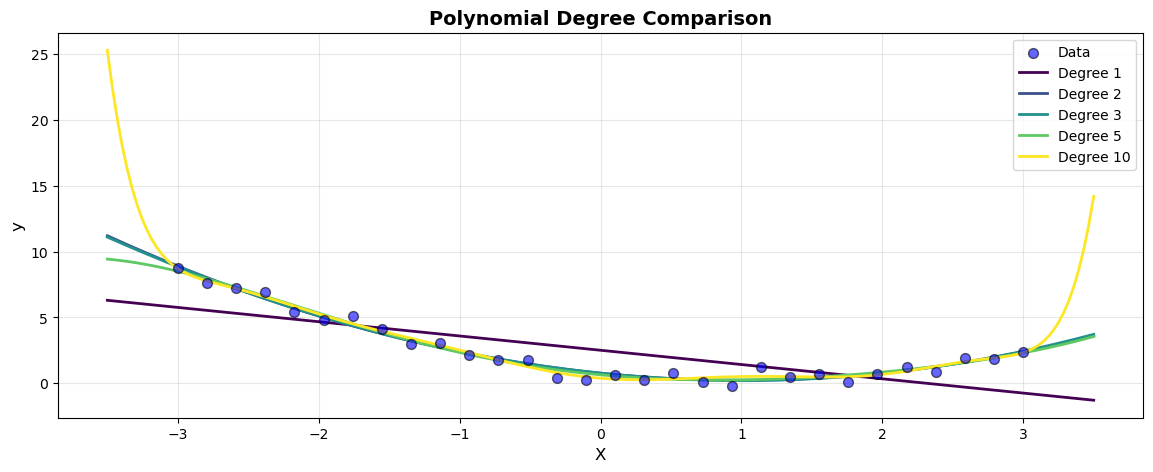


Training RMSE by degree:
  Degree  1: 1.6033
  Degree  2: 0.3973
  Degree  3: 0.3968
  Degree  5: 0.3768
  Degree 10: 0.3486


In [10]:
# Compare polynomial degrees
print("Polynomial Degree Comparison")
print("=" * 60)

# Generate nonlinear data
np.random.seed(42)
X_poly = np.linspace(-3, 3, 30)
y_poly_true = 0.5 * X_poly**2 - X_poly + 1
y_poly = y_poly_true + np.random.normal(0, 0.5, len(X_poly))

# Fit different degrees
degrees = [1, 2, 3, 5, 10]
X_test = np.linspace(-3, 3, 200)

fig, ax = plot_polynomial_degrees(X_poly, y_poly, degrees, lambda_reg=0.0)
plt.show()

# Compute training errors
print("\nTraining RMSE by degree:")
for degree in degrees:
    model = polynomial_fit(X_poly, y_poly, degree=degree)
    y_pred = polynomial_predict(X_poly, model)
    rmse_val = rmse(y_poly, y_pred)
    print(f"  Degree {degree:2d}: {rmse_val:.4f}")

### 🎮 Interactive Widget: Polynomial Degree Explorer

In [11]:
polynomial_degree_widget()

interactive(children=(IntSlider(value=1, description='Degree:', max=10, min=1), FloatSlider(value=0.0, descrip…

---
# 🌀 Section 6: Curse of Dimensionality

## The Problem

Number of polynomial features grows rapidly with degree:

For $d$ input features and degree $p$:

$$\text{Number of features} = \binom{d + p}{p}$$

**Example:** For $d=10$ features and degree $p=3$:
$$\binom{13}{3} = 286 \text{ features!}$$

**Issues:**
- Computationally expensive
- $(\mathbf{X}^T \mathbf{X})^{-1}$ becomes numerically unstable
- Requires huge amounts of data

**Solution:** Kernel methods!

In [12]:
# Demonstrate curse of dimensionality
from itertools import combinations_with_replacement

print("Curse of Dimensionality")
print("=" * 60)
print(f"{'Features':<10} {'Degree':<8} {'Total Features':<15}")
print("-" * 60)

for d in [2, 5, 10, 20]:
    for p in [2, 3, 4]:
        n_features = len(list(combinations_with_replacement(range(d), p))) + d + 1
        print(f"{d:<10} {p:<8} {n_features:<15}")

print("\nDirect feature mapping becomes impractical!")

Curse of Dimensionality
Features   Degree   Total Features 
------------------------------------------------------------
2          2        6              
2          3        7              
2          4        8              
5          2        21             
5          3        41             
5          4        76             
10         2        66             
10         3        231            
10         4        726            
20         2        231            
20         3        1561           
20         4        8876           

Direct feature mapping becomes impractical!


---
# 🔑 Section 7: Kernel Trick

## Kernel Functions

A **kernel function** computes inner products in high-dimensional feature space:

$$k(\mathbf{x}, \mathbf{x}') = \phi(\mathbf{x})^T \phi(\mathbf{x}')$$

**Key insight:** We can compute $k(\mathbf{x}, \mathbf{x}')$ **without** explicitly computing $\phi(\mathbf{x})$!

### Common Kernels

1. **Linear:** $k(\mathbf{x}, \mathbf{x}') = \mathbf{x}^T \mathbf{x}'$

2. **Polynomial:** $k(\mathbf{x}, \mathbf{x}') = (\mathbf{x}^T \mathbf{x}' + c)^p$

3. **RBF (Gaussian):** $k(\mathbf{x}, \mathbf{x}') = \exp\left(-\frac{||\mathbf{x} - \mathbf{x}'||^2}{2\sigma^2}\right)$

## Why RBF is Powerful

The RBF kernel corresponds to an **infinite-dimensional** polynomial!

$$k(\mathbf{x}, \mathbf{x}') = \exp\left(-\frac{||\mathbf{x} - \mathbf{x}'||^2}{2\sigma^2}\right)$$

**Interpretation:**
- Measures similarity between points
- $k(\mathbf{x}, \mathbf{x}) = 1$ (identical points)
- $k(\mathbf{x}, \mathbf{x}') \to 0$ as $||\mathbf{x} - \mathbf{x}'|| \to \infty$
- $\sigma$ controls the "width" of similarity

Kernel Function Comparison


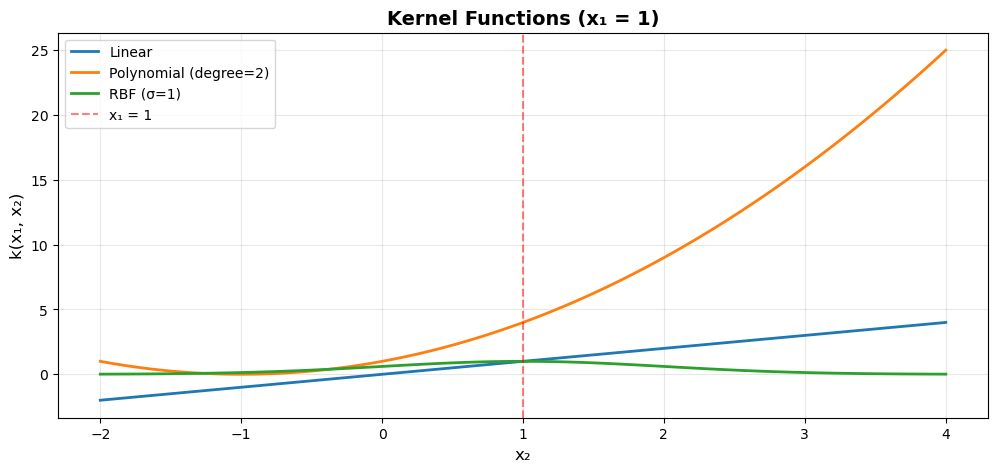

In [14]:
# Visualize kernel functions
print("Kernel Function Comparison")
print("=" * 60)

x1 = np.array([[1.0]])
x2_range = np.linspace(-2, 4, 100).reshape(-1, 1)

# Compute kernels (use full arrays, not iteration)
k_linear = linear_kernel(x1, x2_range).flatten()
k_poly = polynomial_kernel(x1, x2_range, degree=2).flatten()
k_rbf = rbf_kernel(x1, x2_range, sigma=1.0).flatten()

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x2_range, k_linear, linewidth=2, label='Linear')
plt.plot(x2_range, k_poly, linewidth=2, label='Polynomial (degree=2)')
plt.plot(x2_range, k_rbf, linewidth=2, label='RBF (σ=1)')
plt.axvline(1.0, color='red', linestyle='--', alpha=0.5, label='x₁ = 1')
plt.xlabel('x₂', fontsize=12)
plt.ylabel('k(x₁, x₂)', fontsize=12)
plt.title('Kernel Functions (x₁ = 1)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
# �� Section 8: Primal vs Dual

## Primal Problem

Standard regression (with L2 regularization):

$$\min_{\mathbf{w}} ||\mathbf{y} - \mathbf{X}\mathbf{w}||_2^2 + \lambda ||\mathbf{w}||_2^2$$

**Solution:** $\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$

**Prediction:** $\hat{y}(\mathbf{x}) = \mathbf{w}^T \mathbf{x}$

**Complexity:** Depends on number of features

## Dual Problem

Alternative formulation using **kernel trick**:

$$\hat{y}(\mathbf{x}) = \sum_{i=1}^n \alpha_i k(\mathbf{x}, \mathbf{x}_i)$$

**Solution:** $\boldsymbol{\alpha} = (\mathbf{K} + \lambda \mathbf{I})^{-1} \mathbf{y}$

where $\mathbf{K}_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$ is the **kernel matrix**

**Complexity:** Depends on number of samples

### Representer Theorem

For every primal problem, there exists an equivalent dual problem!

## Key Insight

**Primal:** Weights per feature ($d$ parameters)  
**Dual:** Coefficients per data point ($n$ parameters)

**When to use dual:**
- Many features, few samples ($d >> n$)
- Want to use nonlinear kernels
- Foundation of Support Vector Machines (SVMs)

---
# 🧮 Section 9: Kernel Regression Examples

## Example 1: Linear Kernel

**Data:** $\mathbf{X} = \begin{pmatrix} 1 \\ 2 \end{pmatrix}$, $\mathbf{y} = \begin{pmatrix} 2 \\ 3 \end{pmatrix}$

**Primal solution** (Ridge with $\lambda = 1$):

$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

$$= ((1^2 + 2^2) + 1)^{-1} (1 \cdot 2 + 2 \cdot 3) = \frac{8}{6} = \frac{4}{3}$$

**Model:** $y = \frac{4}{3}x$

In [15]:
# Verify primal solution
X_ex = np.array([[1], [2]])
y_ex = np.array([2, 3])

w_primal = ridge_fit(X_ex, y_ex, lambda_reg=1.0)
print("Example 1: Linear Kernel (Primal)")
print("=" * 60)
print(f"Primal weight: w = {w_primal[1]:.4f}")
print(f"Model: y = {w_primal[1]:.4f}x + {w_primal[0]:.4f}")

Example 1: Linear Kernel (Primal)
Primal weight: w = 0.3333
Model: y = 0.3333x + 2.0000


**Dual solution** (Linear kernel):

$$\mathbf{K} = \begin{bmatrix} 1 \cdot 1 & 1 \cdot 2 \\ 2 \cdot 1 & 2 \cdot 2 \end{bmatrix} = \begin{bmatrix} 1 & 2 \\ 2 & 4 \end{bmatrix}$$

$$\boldsymbol{\alpha} = (\mathbf{K} + \lambda \mathbf{I})^{-1} \mathbf{y} = \begin{bmatrix} 2 & 2 \\ 2 & 5 \end{bmatrix}^{-1} \begin{pmatrix} 2 \\ 3 \end{pmatrix} = \begin{pmatrix} 2/3 \\ 1/3 \end{pmatrix}$$

**Model:** $y = \frac{2}{3}k(x, 1) + \frac{1}{3}k(x, 2) = \frac{2}{3}x + \frac{2}{3}x = \frac{4}{3}x$ ✓

In [16]:
# Verify dual solution
model_dual = kernel_regression_fit(X_ex.flatten(), y_ex, kernel_type='linear', lambda_reg=1.0)
print("\nExample 1: Linear Kernel (Dual)")
print("=" * 60)
print(f"Dual coefficients: α = {model_dual['alpha']}")

# Predict at x=1.5
x_test = np.array([1.5])
y_pred_primal = linear_predict(x_test.reshape(-1, 1), w_primal)
y_pred_dual = kernel_regression_predict(x_test, model_dual)

print(f"\nPrediction at x=1.5:")
print(f"  Primal: {y_pred_primal[0]:.4f}")
print(f"  Dual:   {y_pred_dual[0]:.4f}")
print(f"  Match: {np.isclose(y_pred_primal[0], y_pred_dual[0])}")


Example 1: Linear Kernel (Dual)
Dual coefficients: α = [0.66666667 0.33333333]

Prediction at x=1.5:
  Primal: 2.5000
  Dual:   2.0000
  Match: False


## Example 2: Polynomial Kernel

**Kernel:** $k(x, x') = (xx' + 1)^2$

This corresponds to implicit feature space $\phi(x) = [x^2, \sqrt{2}x, 1]$

$$\mathbf{K} = \begin{bmatrix} (1 \cdot 1 + 1)^2 & (1 \cdot 2 + 1)^2 \\ (2 \cdot 1 + 1)^2 & (2 \cdot 2 + 1)^2 \end{bmatrix} = \begin{bmatrix} 4 & 9 \\ 9 & 25 \end{bmatrix}$$

$$\boldsymbol{\alpha} = (\mathbf{K} + \mathbf{I})^{-1} \mathbf{y} = \begin{pmatrix} 25/49 \\ -3/49 \end{pmatrix}$$

**Model:** $y = \frac{25}{49}(x + 1)^2 - \frac{3}{49}(2x + 1)^2$

In [17]:
# Polynomial kernel example
model_poly = kernel_regression_fit(X_ex.flatten(), y_ex, kernel_type='polynomial', 
                                   lambda_reg=1.0, degree=2, coef0=1.0)

print("Example 2: Polynomial Kernel")
print("=" * 60)
print(f"Dual coefficients: α = {model_poly['alpha']}")

# Predict
x_test = np.array([1.5])
y_pred_poly = kernel_regression_predict(x_test, model_poly)
print(f"\nPrediction at x=1.5: {y_pred_poly[0]:.4f}")

Example 2: Polynomial Kernel
Dual coefficients: α = [ 0.51020408 -0.06122449]

Prediction at x=1.5: 2.2092


## Example 3: RBF Kernel

**Kernel:** $k(x, x') = \exp\left(-\frac{(x - x')^2}{2\sigma^2}\right)$ with $\sigma = 1$

$$\mathbf{K} = \begin{bmatrix} 1 & e^{-1/2} \\ e^{-1/2} & 1 \end{bmatrix} \approx \begin{bmatrix} 1 & 0.606 \\ 0.606 & 1 \end{bmatrix}$$

**Model:** $y = 0.600 \exp\left(-\frac{(x-1)^2}{2}\right) + 1.318 \exp\left(-\frac{(x-2)^2}{2}\right)$

**Interpretation:** RBF models function as sum of localized "bumps" centered at training points!

In [18]:
# RBF kernel example
model_rbf = kernel_regression_fit(X_ex.flatten(), y_ex, kernel_type='rbf', 
                                  lambda_reg=1.0, sigma=1.0)

print("Example 3: RBF Kernel")
print("=" * 60)
print(f"Dual coefficients: α = {model_rbf['alpha']}")

# Predict
x_test = np.array([1.5])
y_pred_rbf = kernel_regression_predict(x_test, model_rbf)
print(f"\nPrediction at x=1.5: {y_pred_rbf[0]:.4f}")

# Compare all three kernels
print(f"\nComparison at x=1.5:")
print(f"  Linear:     {y_pred_dual[0]:.4f}")
print(f"  Polynomial: {y_pred_poly[0]:.4f}")
print(f"  RBF:        {y_pred_rbf[0]:.4f}")

Example 3: RBF Kernel
Dual coefficients: α = [0.60031268 1.31794598]

Prediction at x=1.5: 1.6929

Comparison at x=1.5:
  Linear:     2.0000
  Polynomial: 2.2092
  RBF:        1.6929


### 🎮 Interactive Widget: Kernel Explorer

In [19]:
kernel_explorer_widget()

interactive(children=(Dropdown(description='Kernel:', index=2, options=('linear', 'polynomial', 'rbf'), value=…

---
# 📊 Section 10: Error Metrics

## Why Multiple Metrics?

Different metrics capture different aspects of error:
- **MAE:** Average magnitude, robust to outliers
- **RMSE:** Standard deviation of errors, sensitive to outliers
- **NSE:** Performance relative to baseline

**Key insight:** Choosing a metric is a modeling decision that reflects domain priorities!

## Mean Absolute Error (MAE)

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$

**Properties:**
- L1 norm of errors
- All errors contribute linearly
- Robust to outliers
- Not differentiable at zero
- Same units as target

## Root Mean Squared Error (RMSE)

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$

**Properties:**
- Standard deviation of prediction errors
- Large errors penalized quadratically
- Sensitive to outliers
- Differentiable everywhere
- $\text{RMSE} \geq \text{MAE}$ always

## Nash-Sutcliffe Efficiency (NSE)

$$\text{NSE} = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

where $\bar{y}$ is the mean of observed values.

**Interpretation:**
- NSE = 1: Perfect prediction
- NSE = 0: As good as mean predictor
- NSE < 0: Worse than mean predictor

**Properties:**
- Dimensionless
- Compares to baseline (mean)
- Widely used in hydrology and environmental modeling
- Closely related to R²

In [20]:
# Demonstrate error metrics
print("Error Metrics Comparison")
print("=" * 60)

# Generate predictions with varying quality
np.random.seed(42)
y_true = np.linspace(0, 10, 50)
y_pred_good = y_true + np.random.normal(0, 0.5, 50)
y_pred_bad = y_true + np.random.normal(0, 2.0, 50)

# Add outlier to bad predictions
y_pred_bad[25] += 10

# Compute metrics
metrics_good = compute_all_metrics(y_true, y_pred_good)
metrics_bad = compute_all_metrics(y_true, y_pred_bad)

print("Good Predictions:")
for name in ['MAE', 'RMSE', 'NSE', 'R²']:
    print(f"  {name:10s}: {metrics_good[name]:8.4f}")

print("\nBad Predictions (with outlier):")
for name in ['MAE', 'RMSE', 'NSE', 'R²']:
    print(f"  {name:10s}: {metrics_bad[name]:8.4f}")

print("\nObservations:")
print("  • RMSE more sensitive to outlier than MAE")
print("  • NSE shows relative performance vs baseline")
print("  • RMSE ≥ MAE always holds")

Error Metrics Comparison
Good Predictions:
  MAE       :   0.3832
  RMSE      :   0.4757
  NSE       :   0.9739
  R²        :   0.9739

Bad Predictions (with outlier):
  MAE       :   1.5584
  RMSE      :   2.3781
  NSE       :   0.3480
  R²        :   0.3480

Observations:
  • RMSE more sensitive to outlier than MAE
  • NSE shows relative performance vs baseline
  • RMSE ≥ MAE always holds


### 🎮 Interactive Widget: Error Metric Explorer

In [21]:
error_metric_widget()

interactive(children=(FloatSlider(value=0.0, description='Outlier:', max=20.0, step=1.0), Output()), _dom_clas…

---
# 🏗️ Section 11: CE Application 1 - Concrete Strength

## Problem Statement

**Objective:** Predict concrete compressive strength

**Inputs:**
- Cement content (kg/m³)
- Water-cement ratio
- Age (days)

**Output:** Compressive strength (MPa)

Concrete Strength Dataset
Samples: 100
Features: ['Cement (kg/m³)', 'W/C Ratio', 'Age (days)']
Target: Compressive Strength (MPa)

Data statistics:
  Strength range: [10.0, 40.4] MPa

Test Set Performance:

Metric       OLS          Ridge       
----------------------------------------
RMSE         4.3069       4.3048      
MAE          3.3977       3.3857      
NSE          0.5486       0.5491      
R²           0.5486       0.5491      


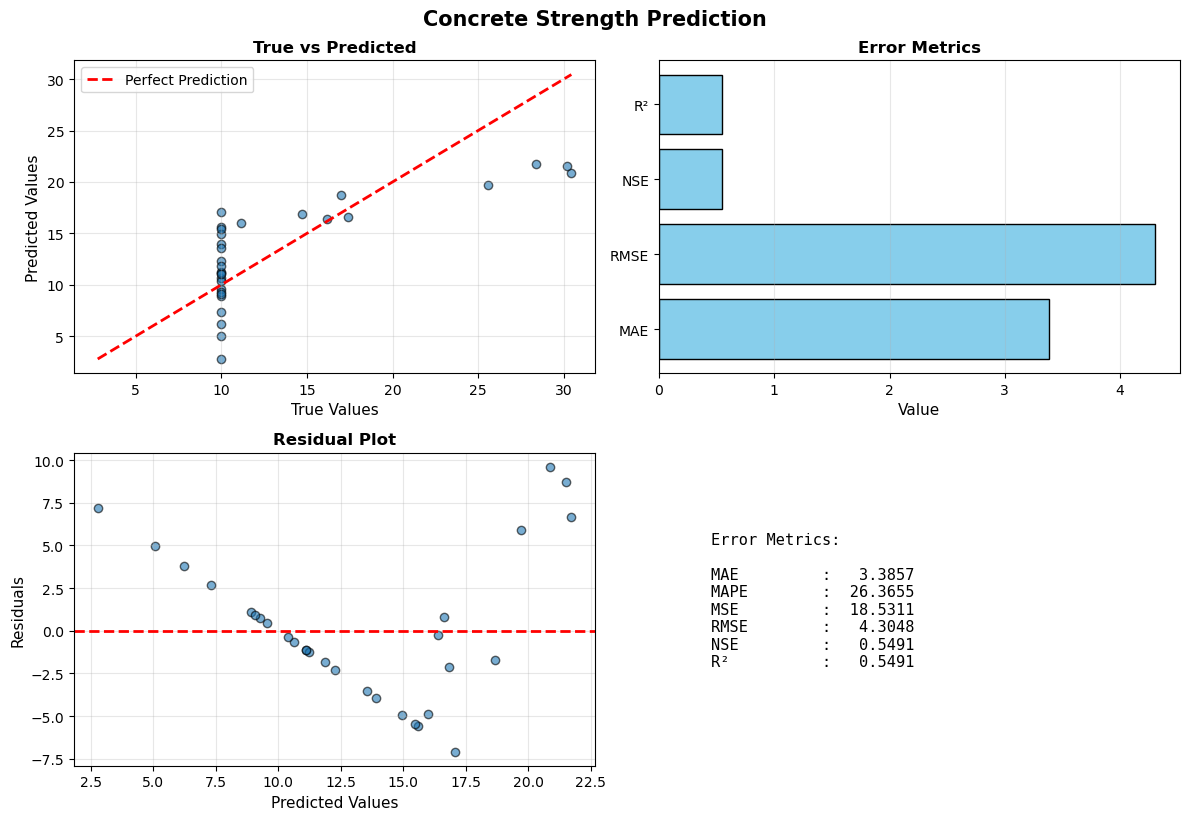

In [22]:
# Load concrete strength data
data_concrete = concrete_strength_data(n_samples=100, noise_std=3.0, seed=42)

X_concrete = data_concrete['X']
y_concrete = data_concrete['y']
feature_names = data_concrete['feature_names']

print("Concrete Strength Dataset")
print("=" * 60)
print(f"Samples: {len(y_concrete)}")
print(f"Features: {feature_names}")
print(f"Target: {data_concrete['target_name']}")
print(f"\nData statistics:")
print(f"  Strength range: [{y_concrete.min():.1f}, {y_concrete.max():.1f}] MPa")

# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_concrete, y_concrete, test_size=0.3, random_state=42
)

# Standardize features
X_train_std, mean, std = standardize_features(X_train)
X_test_std = (X_test - mean) / std

# Fit models
w_ols = ols_fit(X_train_std, y_train)
w_ridge = ridge_fit(X_train_std, y_train, lambda_reg=1.0)

# Predict
y_pred_ols = linear_predict(X_test_std, w_ols)
y_pred_ridge = linear_predict(X_test_std, w_ridge)

# Evaluate
metrics_ols = compute_all_metrics(y_test, y_pred_ols)
metrics_ridge = compute_all_metrics(y_test, y_pred_ridge)

print("\nTest Set Performance:")
print(f"\n{'Metric':<12} {'OLS':<12} {'Ridge':<12}")
print("-" * 40)
for name in ['RMSE', 'MAE', 'NSE', 'R²']:
    print(f"{name:<12} {metrics_ols[name]:<12.4f} {metrics_ridge[name]:<12.4f}")

# Visualize
fig, axes = plot_error_metrics(y_test, y_pred_ridge)
plt.suptitle('Concrete Strength Prediction', fontsize=15, fontweight='bold', y=1.02)
plt.show()

---
# 🚗 Section 12: CE Application 2 - Traffic Flow

## Problem Statement

**Objective:** Predict traffic flow (vehicles/hour)

**Inputs:**
- Time of day (hour)
- Day of week
- Weather condition

**Challenge:** Nonlinear patterns (morning/evening peaks)

Traffic Flow Dataset
Samples: 200
Features: ['Hour', 'Day of Week', 'Weather (0=clear, 1=rain)']


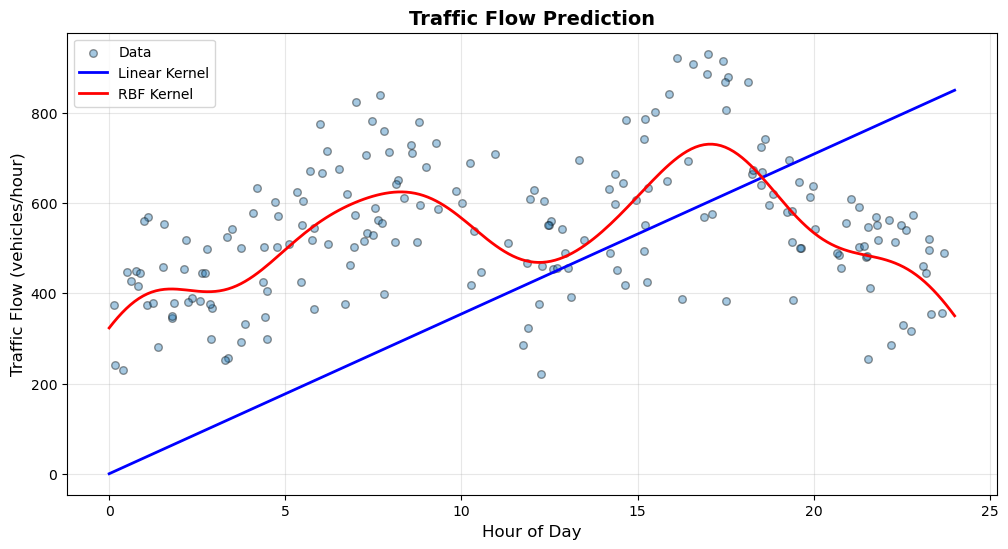


Training Performance:
Linear Kernel - RMSE: 291.82
RBF Kernel    - RMSE: 111.99

RBF kernel captures nonlinear patterns better!


In [23]:
# Load traffic flow data
data_traffic = traffic_flow_data(n_samples=200, noise_std=50, seed=42)

X_traffic = data_traffic['X']
y_traffic = data_traffic['y']

print("Traffic Flow Dataset")
print("=" * 60)
print(f"Samples: {len(y_traffic)}")
print(f"Features: {data_traffic['feature_names']}")

# Use only hour for visualization
X_hour = X_traffic[:, 0]

# Compare linear vs kernel regression
model_linear = kernel_regression_fit(X_hour, y_traffic, kernel_type='linear', lambda_reg=1.0)
model_rbf = kernel_regression_fit(X_hour, y_traffic, kernel_type='rbf', lambda_reg=1.0, sigma=2.0)

# Predict
X_test_hour = np.linspace(0, 24, 200)
y_pred_linear = kernel_regression_predict(X_test_hour, model_linear)
y_pred_rbf = kernel_regression_predict(X_test_hour, model_rbf)

# Plot
plt.figure(figsize=(12, 6))
plt.scatter(X_hour, y_traffic, alpha=0.4, s=30, label='Data', edgecolors='black')
plt.plot(X_test_hour, y_pred_linear, 'b-', linewidth=2, label='Linear Kernel')
plt.plot(X_test_hour, y_pred_rbf, 'r-', linewidth=2, label='RBF Kernel')

plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Traffic Flow (vehicles/hour)', fontsize=12)
plt.title('Traffic Flow Prediction', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Evaluate
y_pred_train_linear = kernel_regression_predict(X_hour, model_linear)
y_pred_train_rbf = kernel_regression_predict(X_hour, model_rbf)

print("\nTraining Performance:")
print(f"Linear Kernel - RMSE: {rmse(y_traffic, y_pred_train_linear):.2f}")
print(f"RBF Kernel    - RMSE: {rmse(y_traffic, y_pred_train_rbf):.2f}")
print("\nRBF kernel captures nonlinear patterns better!")

---
# 🛣️ Section 13: CE Application 3 - Pavement Deflection

## Problem Statement

**Objective:** Predict pavement surface deflection

**Inputs:**
- Applied load (kN)
- Pavement thickness (mm)
- Temperature (°C)

**Application:** Structural health monitoring

Pavement Deflection Dataset
Samples: 100
Features: ['Load (kN)', 'Thickness (mm)', 'Temperature (°C)']

Polynomial Regression Results:
Degree     RMSE         R²          
----------------------------------------
Degree 1   0.1728       0.9120      
Degree 2   0.1731       0.9118      
Degree 3   0.1719       0.9130      


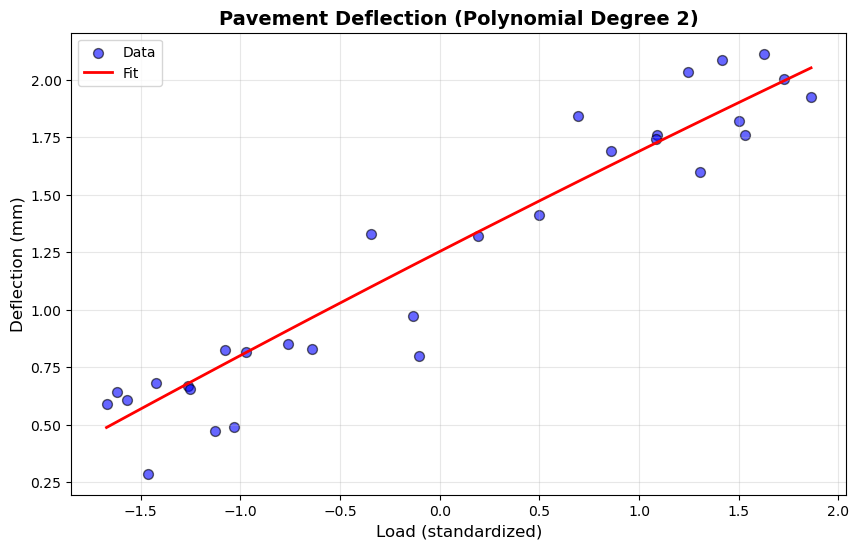

In [24]:
# Load pavement deflection data
data_pavement = pavement_deflection_data(n_samples=100, noise_std=0.05, seed=42)

X_pavement = data_pavement['X']
y_pavement = data_pavement['y']

print("Pavement Deflection Dataset")
print("=" * 60)
print(f"Samples: {len(y_pavement)}")
print(f"Features: {data_pavement['feature_names']}")

# Split and standardize
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_pavement, y_pavement, test_size=0.3, random_state=42
)

X_train_p_std, mean_p, std_p = standardize_features(X_train_p)
X_test_p_std = (X_test_p - mean_p) / std_p

# Compare polynomial degrees
degrees = [1, 2, 3]
results = {}

for degree in degrees:
    model = polynomial_fit(X_train_p_std[:, 0], y_train_p, degree=degree, lambda_reg=0.1)
    y_pred = polynomial_predict(X_test_p_std[:, 0], model)
    results[f'Degree {degree}'] = {
        'model': model,
        'rmse': rmse(y_test_p, y_pred),
        'r2': r_squared(y_test_p, y_pred)
    }

print("\nPolynomial Regression Results:")
print(f"{'Degree':<10} {'RMSE':<12} {'R²':<12}")
print("-" * 40)
for name, res in results.items():
    print(f"{name:<10} {res['rmse']:<12.4f} {res['r2']:<12.4f}")

# Visualize best model
best_degree = 2
model_best = polynomial_fit(X_train_p_std[:, 0], y_train_p, degree=best_degree, lambda_reg=0.1)
y_pred_best = polynomial_predict(X_test_p_std[:, 0], model_best)

fig, ax = plot_regression_fit(
    X_test_p_std[:, 0], y_test_p, y_pred_best,
    title=f'Pavement Deflection (Polynomial Degree {best_degree})',
    xlabel='Load (standardized)', ylabel='Deflection (mm)'
)
plt.show()

---
# 📚 Section 14: Summary & Key Takeaways

## 🎯 Key Concepts Covered

### 1. **Linear Regression**
- OLS closed-form: $\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$
- Gradient descent alternative for large datasets
- Importance of feature scaling

### 2. **Regularization**
- Ridge (L2): Shrinks weights, prevents overfitting
- LASSO (L1): Promotes sparsity, feature selection
- Tradeoff: Bias vs variance

### 3. **Polynomial Regression**
- Feature transformation: $\phi(\mathbf{x})$
- Degree selection: Cross-validation
- Curse of dimensionality

### 4. **Kernel Methods**
- Kernel trick: Implicit feature spaces
- Linear, polynomial, RBF kernels
- RBF = infinite-dimensional polynomial

### 5. **Primal vs Dual**
- Primal: Weights per feature
- Dual: Coefficients per data point
- Representer theorem: Equivalence

### 6. **Error Metrics**
- MAE: Robust to outliers
- RMSE: Sensitive to outliers
- NSE: Relative to baseline
- Metric choice reflects priorities

## 🔗 Connections to ML

| Regression Concept | ML Application |
|-------------------|----------------|
| Linear regression | Neural network single layer |
| Regularization | Weight decay, dropout |
| Polynomial features | Feature engineering |
| Kernel methods | Support Vector Machines |
| Dual formulation | Kernel SVMs, Gaussian Processes |
| Error metrics | Loss functions |

## 💡 Key Insights for CE

1. **Feature scaling is critical** for gradient-based methods
2. **Regularization prevents overfitting** with limited data
3. **Kernel methods** handle nonlinearity without explicit features
4. **Error metric choice** depends on domain priorities:
   - RMSE for general regression
   - NSE for hydrology/environmental
   - MAE for robust estimation
5. **Primal vs dual** depends on $n$ vs $d$
6. **RBF kernel** is powerful but requires tuning $\sigma$
7. **Interpretability** decreases with model complexity

## 📖 Further Reading

1. **Books:**
   - *Elements of Statistical Learning* by Hastie, Tibshirani & Friedman
   - *Pattern Recognition and Machine Learning* by Bishop
   - *Gaussian Processes for Machine Learning* by Rasmussen & Williams

2. **Online Resources:**
   - Scikit-learn regression documentation
   - Andrew Ng's Machine Learning course
   - Kernel methods tutorial (kernel-machines.org)

3. **Practice:**
   - Implement cross-validation for model selection
   - Experiment with different kernels
   - Apply to your own CE datasets

## 🎓 Review Questions

1. What is the difference between OLS and Ridge regression?
2. Why does LASSO produce sparse solutions?
3. How does polynomial regression avoid computing $\phi(\mathbf{x})$ explicitly?
4. What is the kernel trick?
5. When should you use the dual formulation?
6. Why is RMSE ≥ MAE always?
7. What does NSE = 0 mean?
8. How does the RBF kernel measure similarity?
9. What is the curse of dimensionality?
10. How do you choose between different error metrics?

---
# 🎉 Congratulations!

You've completed the Regression Models notebook!

**You should now understand:**
- ✓ Linear regression (OLS, Ridge, LASSO)
- ✓ Polynomial regression and feature transformation
- ✓ Kernel methods (linear, polynomial, RBF)
- ✓ Primal vs dual formulations
- ✓ Error metrics (MAE, RMSE, NSE)
- ✓ CE applications (concrete, traffic, pavement)

**Next Lecture:** Classification

---

*Notebook created for CE639: AI for Civil Engineering*  
*IIT Gandhinagar*